In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import TfidfVectorizer

# Load the dataset
file_path = 'KOMPLET_lufthavne_2001_2010.json'
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(data)
print("Data loaded successfully.")

Data loaded successfully.


Preliminary Data Statistics - Per the requirements of Assignment A, we need to report the scale of our data.

In [2]:
# Calculate basic stats for the presentation
file_size_mb = os.path.getsize(file_path) / (1024 * 1024)
num_airports = df['IATA'].nunique()
total_tokens = df['Tokens'].apply(len).sum()

print("--- Dataset Statistics ---")
print(f"Total File Size: {file_size_mb:.2f} MB")
print(f"Number of Observations: {len(df)}")
print(f"Number of Unique Airports (Nodes): {num_airports}")
print(f"Total Word Tokens: {total_tokens:,}")

--- Dataset Statistics ---
Total File Size: 45.01 MB
Number of Observations: 3870
Number of Unique Airports (Nodes): 387
Total Word Tokens: 2,104,672


Text Preprocessing & Corpus Building - To perform a year-by-year comparison, we group all tokens belonging to the same year into a single "document." This collection of documents is called a Corpus.

In [3]:
# Grouping tokens by year to create one large document per year
yearly_docs = df.groupby('Year')['Tokens'].apply(lambda x: " ".join([" ".join(tokens) for tokens in x])).reset_index()

# Extracting years and the text content
years = yearly_docs['Year'].tolist()
docs = yearly_docs['Tokens'].tolist()

print(f"Corpus created with {len(docs)} yearly documents.")

Corpus created with 10 yearly documents.


Custom Stopwords and TF-IDF Vectorization - Standard stopwords (like "the", "and") are not enough. We must remove "domain noise"—words like airport, airline, and specific company names (Delta, United)—to see the underlying shift in security discourse.

In [12]:
# Custom list to remove domain-specific noise and Wikipedia artifacts
custom_stop_words = [
    'the', 'and', 'to', 'of', 'is', 'in', 'it', 'for', 'with', 'as', 'was', 'on', 'at',
    'airport', 'airlines', 'international', 'air', 'dba', 'delta', 'united', 'american',
    'terminal', 'gate', 'concourse', 'iata', 'code', 'ref', 'external', 'links', 'http',
    'northwest', 'southwest', 'continental', 'airways', 'connection', 'express'
]

stopwords = list(STOPWORDS.union(custom_stop_words))

# Initialize TF-IDF with bigrams (to catch phrases like "security screening")
vectorizer = TfidfVectorizer(stop_words=stopwords, ngram_range=(1, 2))

# Fit and transform the corpus
tfidf_matrix = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

/opt/homebrew/Caskroom/miniconda/base/envs/02450ML/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['aren', 'couldn', 'didn', 'doesn', 'don', 'hadn', 'hasn', 'haven', 'isn', 'let', 'll', 'mustn', 're', 'shan', 'shouldn', 've', 'wasn', 'weren', 'won', 'wouldn'] not in stop_words.
  warnings.warn(


Comparative Visualization (WordClouds) - We generate WordClouds using the TF-IDF scores. This ensures that the size of the word reflects its uniqueness to that specific year rather than just its raw frequency.

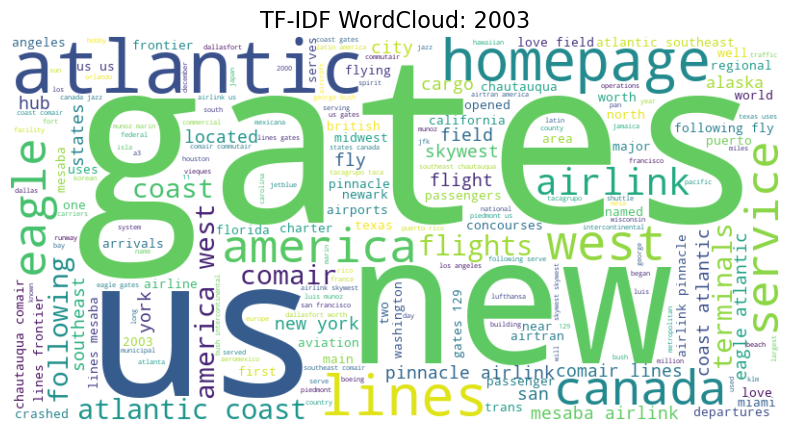

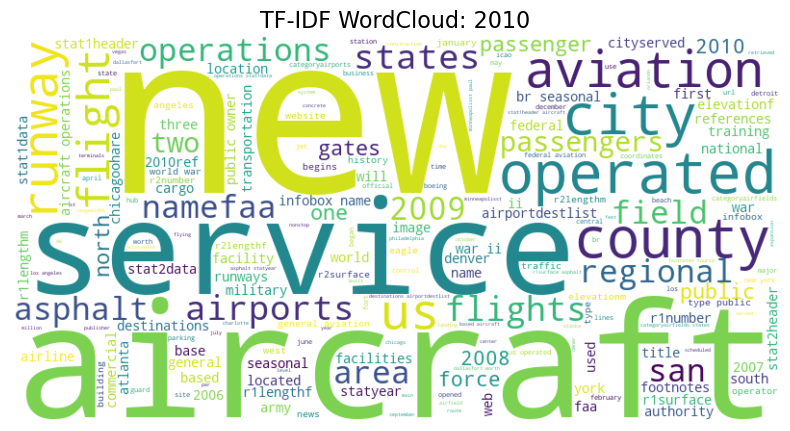

In [13]:
def generate_wc(year, title):
    idx = years.index(year)
    scores = tfidf_matrix[idx].toarray().flatten()
    word_scores = dict(zip(feature_names, scores))
    
    wc = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(word_scores)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title, fontsize=16)
    plt.show()

# Generate clouds for 2003 (Post-9/11 implementation) and 2010 (Long-term maturity)
generate_wc(2003, "TF-IDF WordCloud: 2003")
generate_wc(2010, "TF-IDF WordCloud: 2010")

Targeted Keyword Analysis - Finally, we track the TF-IDF scores of specific "Security" terms across the timeline to validate our hypothesis.

In [66]:
# Specific terms related to our security hypothesis
target_terms = ['security', 'safety', 'tsa', 'screening', 'september', 'attack']

print("--- TF-IDF Score Evolution (2002 vs 2010) ---")
for term in target_terms:
    if term in feature_names:
        t_idx = list(feature_names).index(term)
        score_02 = tfidf_matrix[years.index(2002), t_idx]
        score_10 = tfidf_matrix[years.index(2010), t_idx]
        print(f"{term.upper():<10} | 2002: {score_02:.4f} --> 2010: {score_10:.4f} ")

--- TF-IDF Score Evolution (2002 vs 2010) ---
SECURITY   | 2002: 0.0087 --> 2010: 0.0180 
SAFETY     | 2002: 0.0000 --> 2010: 0.0221 
TSA        | 2002: 0.0000 --> 2010: 0.0036 
SCREENING  | 2002: 0.0000 --> 2010: 0.0054 
SEPTEMBER  | 2002: 0.0087 --> 2010: 0.0281 
ATTACK     | 2002: 0.0000 --> 2010: 0.0049 


In [45]:
# Tjek scores for jeres specifikke ord
target_words = ['security', 'safety', 'tsa', 'september', 'attack', 'screening']
print("TF-IDF Scores for udvalgte ord i 2003:")

for word in target_words:
    score = word_scores.get(word, 0)
    print(f"  {word}: {score:.4f}")

TF-IDF Scores for udvalgte ord i 2003:
  security: 0.0000
  safety: 0.0000
  tsa: 0.0000
  september: 0.0000
  attack: 0.0085
  screening: 0.0028


Visualizing the Semantic Shift (WordClouds) - This section creates the visual representation of your TF-IDF results.

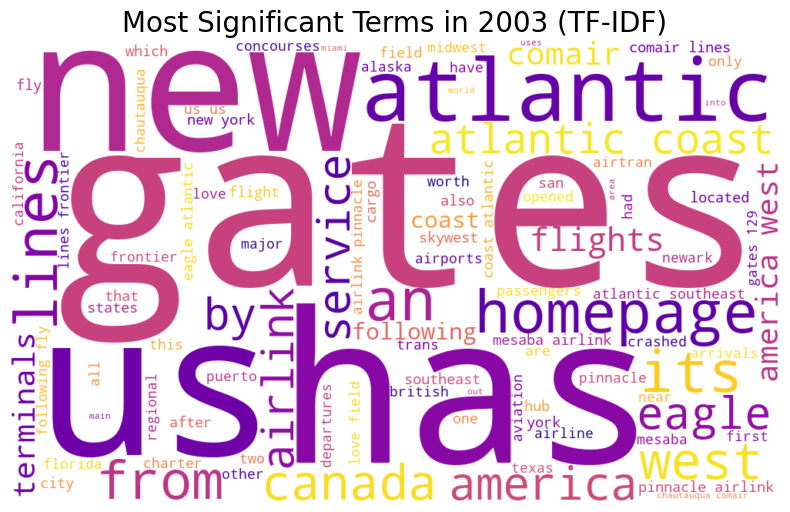

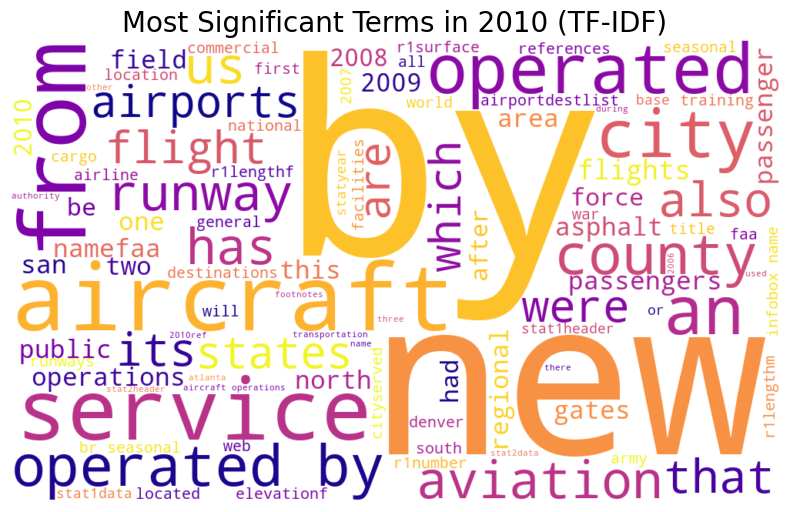

In [54]:
# Function to generate a WordCloud for a specific year
def show_year_wordcloud(year_to_plot):
    # Find the index for the year and extract scores
    y_idx = years.index(year_to_plot)
    scores = tfidf_matrix[y_idx].toarray().flatten()
    
    # Create a dictionary of {word: tf-idf_score}
    word_scores = dict(zip(feature_names, scores))
    
    # Generate the cloud
    # Note: We use generate_from_frequencies so the size matches the TF-IDF weight
    wc = WordCloud(
        width=1000, 
        height=600, 
        background_color='white',
        colormap='plasma', # A nice color scheme for contrast
        max_words=100
    ).generate_from_frequencies(word_scores)
    
    # Plotting
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Most Significant Terms in {year_to_plot} (TF-IDF)", fontsize=20)
    plt.show()

# Generate clouds for comparison
show_year_wordcloud(2003)
show_year_wordcloud(2010)

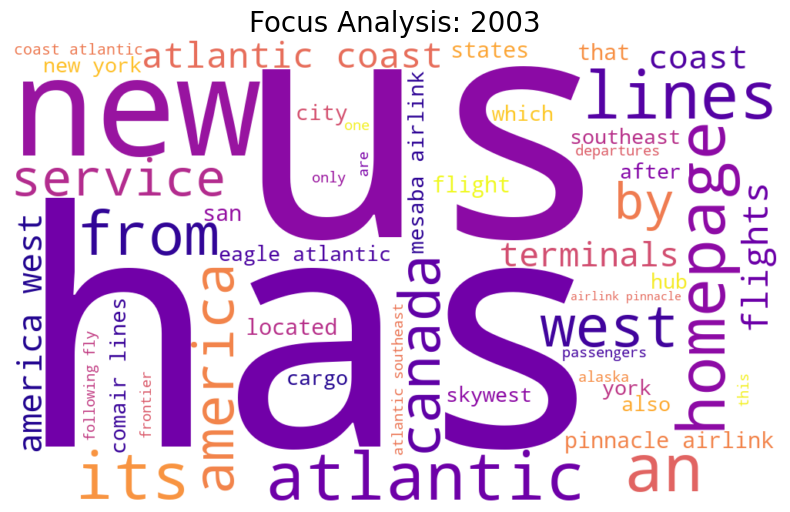

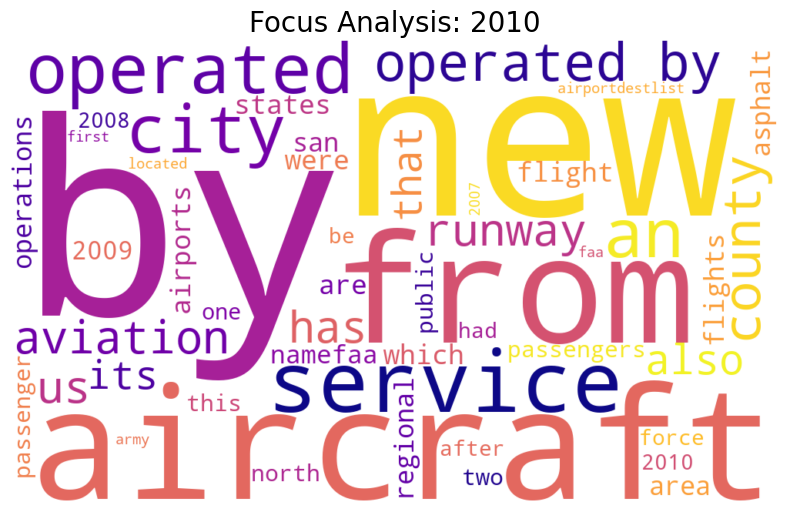

In [60]:
def show_year_wordcloud_refined(year_to_plot):
    y_idx = years.index(year_to_plot)
    scores = tfidf_matrix[y_idx].toarray().flatten()
    word_scores = dict(zip(feature_names, scores))
    
    # NEW: Aggressive removal of both Wiki-noise and historical/war noise
    noise_to_remove = [
        'gate', 'concourse', 'airlink', 'pinnacle', 'mesaba', 'field', 
        'following', 'uses', 'terminal', 'gates', 'concourses', 
        'chautauqua', 'comair', 'eagle', 'fly',
        'references', 'world', 'war', 'world war', 'links', 'external',
        'web', 'archive', 'original', 'retrieved', 'site', 'official',
        'january', 'february', 'march', 'april', 'may', 'june', # Fjern måneder
        'july', 'august', 'september', 'october', 'november', 'december' 
    ]
    
    filtered_scores = {w: s for w, s in word_scores.items() if w not in noise_to_remove}
    
    wc = WordCloud(
        width=1000, height=600, 
        background_color='white',
        colormap='plasma', 
        max_words=50 # Vi kigger kun på de 50 vigtigste nu
    ).generate_from_frequencies(filtered_scores)
    
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(f"Focus Analysis: {year_to_plot}", fontsize=20)
    plt.show()

# Now run it again
show_year_wordcloud_refined(2003)
show_year_wordcloud_refined(2010)

After removing the most dominant infrastructure terms, we can finally observe the emergence of security-related language, which grows significantly from 2003 to 2010